# # 08 — Campaign Ranking (MVP 05)
#
# **Pipeline stage: learn to rank campaigns by expected business value.**
#
# We build a **LightGBM Ranker** (LambdaRank) on query groups of the form
# `product -> campaigns that promoted it`. For each (product, campaign) instance the
# ranker sees only **knowable-in-advance features** (campaign design, product profile,
# promotion mechanics) and learns to order campaigns by observed **business value**
# (a composite of incremental revenue, incremental sales and uplift from MVP 02).
#
# ```
# campaign performance (MVP 02/03) + promotion history (MVP 01) + product features (PI)
#   -> ranking dataset with product-query groups
#   -> LightGBM Ranker + regression baseline (rank by prediction)
#   -> time-based split by campaign start date
#   -> NDCG@k + rank correlation metrics, SHAP explainability
#   -> ranked_campaigns.parquet | models | shap
# ```
#
# **Small-data caveat**: only 30 historical campaigns exist. The ranker is trained for
# structure and as the scaffold for the production ranking service — the regression
# baseline provides a robust alternative and both are compared honestly.


In [1]:
# --- environment --------------------------------------------------------------
import sys
import json
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")

def _find_root() -> Path:
    p = Path.cwd()
    for q in [p, *p.parents]:
        if (q / "data" / "raw" / "transaction_data.csv").exists():
            return q
    return p

ROOT = _find_root()
sys.path.insert(0, str(ROOT / "notebooks"))

from utils import data as UD
from utils import common as UC

logger = UC.setup_logging("campaign_ranking")


@dataclass(frozen=True)
class Config:
    """Single source of truth for MVP 05."""
    seed: int = 42
    n_jobs: int = 8
    min_group_size: int = 2            # products need >= this many campaign docs
    train_share: float = 0.7           # campaigns split by start date (time-based)
    lgb_params: dict = None
    n_estimators: int = 400
    early_stopping: int = 50
    ndcg_k: int = 5
    shap_sample: int = 2000
    output_dir: Path = UC.pipeline_dir("campaign_ranking")
    figures_dir: Path = UC.figures_dir("campaign_ranking")

    def __post_init__(self):
        if self.lgb_params is None:
            object.__setattr__(self, "lgb_params", {
                "learning_rate": 0.05, "num_leaves": 31,
                "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1,
                "min_data_in_leaf": 20, "n_jobs": self.n_jobs,
                "seed": self.seed, "verbosity": -1,
            })


CFG = Config()
UC.set_seed(CFG.seed)
print(f"Output dir  : {CFG.output_dir}")


Output dir  : /home/mhseddighi/Projects/promotion-intelligence/outputs/campaign_ranking


# ## 1. Load Inputs


In [2]:
inc_product = pd.read_parquet(UC.OUTPUTS_ROOT / "baseline_forecast" / "incremental_product.parquet")
campaign_roi = pd.read_parquet(UC.OUTPUTS_ROOT / "roi_analysis" / "campaign_roi_summary.parquet")
promoted = pd.read_parquet(UC.OUTPUTS_ROOT / "promotion_analysis" / "promoted_products.parquet")
campaign_desc = UD.campaign_days(UD.load_campaign_desc())
causal_weekly = UD.load_or_build_causal_weekly(logger=logger)
product_features = pd.read_parquet(UC.OUTPUTS_ROOT / "product_intelligence" / "product_features.parquet")
overlaps_path = UC.OUTPUTS_ROOT / "promotion_analysis" / "campaign_overlaps.parquet"
overlaps = (pd.read_parquet(overlaps_path) if overlaps_path.exists() else pd.DataFrame())

print(f"incremental_product : {inc_product.shape}")
print(f"campaign_roi        : {campaign_roi.shape}")
print(f"promoted            : {promoted.shape}")
print(f"product_features    : {product_features.shape}")


23:01:39 | INFO    | campaign_ranking | Loading cached causal_weekly from /home/mhseddighi/Projects/promotion-intelligence/data/processed/causal_weekly.parquet


incremental_product : (19107, 25)
campaign_roi        : (30, 26)
promoted            : (404361, 12)
product_features    : (92353, 38)


In [3]:
def validate_inputs() -> None:
    assert inc_product["CAMPAIGN"].nunique() == 30
    assert campaign_roi["CAMPAIGN"].nunique() == 30
    assert len(campaign_desc) == 30
    UC.check_no_nan_inf(inc_product[["CAMPAIGN", "PRODUCT_ID", "incremental_qty",
                                     "incremental_rev", "uplift_qty_pct"]],
                        context="incremental_product")
    print("PASS: inputs validated")


validate_inputs()


PASS [nan/inf] incremental_product: no NaN/Inf in 19,107 rows
PASS: inputs validated


# ## 2. Ranking Dataset
#
# One row per (product, campaign) instance. Features are grouped into:
#
# - **Campaign design** — type, duration, start season, concurrent-campaign load.
# - **Product profile** — avg price, product-level discount rate, volatility, category.
# - **Promotion mechanics** — discount depth, display/mailer intensity in the window.
# - **Demand scale** — baseline quantity (so small and large products are comparable).
#
# The target `business_value` is a standardized composite:
# `0.4 × z(incremental_rev) + 0.3 × z(incremental_qty) + 0.3 × z(uplift_qty_pct)`.


In [4]:
inst = (inc_product[["CAMPAIGN", "PRODUCT_ID", "incremental_qty", "incremental_rev",
                     "uplift_qty_pct", "base_qty", "actual_qty", "confidence_qty"]]
        .merge(campaign_desc[["CAMPAIGN", "DESCRIPTION", "START_DAY", "END_DAY",
                              "duration_days"]], on="CAMPAIGN", how="left"))

inst = inst.merge(promoted[["CAMPAIGN", "PRODUCT_ID", "promo_days", "promo_sales",
                            "promo_discount", "discount_depth"]],
                  on=["CAMPAIGN", "PRODUCT_ID"], how="left")

pf = product_features[["PRODUCT_ID", "avg_price", "discount_rate", "sales_frequency",
                       "volatility", "total_sales", "DEPARTMENT", "COMMODITY_DESC"]]
pf = pf.rename(columns={"discount_rate": "product_discount_rate"})
inst = inst.merge(pf, on="PRODUCT_ID", how="left")

# --- display / mailer intensity averaged over the campaign window -------------
inst["start_week"] = np.ceil(inst["START_DAY"] / 7).astype(int)
inst["end_week"] = np.ceil(inst["END_DAY"] / 7).astype(int)
week_rows = []
for _, r in inst[["CAMPAIGN", "PRODUCT_ID", "start_week", "end_week"]].iterrows():
    week_rows.append(pd.DataFrame({
        "CAMPAIGN": r["CAMPAIGN"], "PRODUCT_ID": r["PRODUCT_ID"],
        "WEEK_NO": np.arange(r["start_week"], r["end_week"] + 1)}))
weeks = pd.concat(week_rows, ignore_index=True)
cw = weeks.merge(causal_weekly[["PRODUCT_ID", "WEEK_NO", "display_share", "mailer_share"]],
                 on=["PRODUCT_ID", "WEEK_NO"], how="left")
cw = cw.groupby(["CAMPAIGN", "PRODUCT_ID"], as_index=False).agg(
    display_share=("display_share", "mean"), mailer_share=("mailer_share", "mean"))
inst = inst.merge(cw, on=["CAMPAIGN", "PRODUCT_ID"], how="left")
inst["display_share"] = inst["display_share"].fillna(0.0)
inst["mailer_share"] = inst["mailer_share"].fillna(0.0)

# --- season + concurrent-campaign load ----------------------------------------
inst["month"] = ((inst["START_DAY"] / 30).astype(int) % 12) + 1
inst["quarter"] = ((inst["START_DAY"] / 30).astype(int) % 12 // 3) + 1
if not overlaps.empty:
    overlap_count = (pd.concat([overlaps["campaign_a"], overlaps["campaign_b"]])
                     .value_counts().to_dict())
    inst["overlap_count"] = inst["CAMPAIGN"].map(overlap_count).fillna(0).astype(int)
else:
    inst["overlap_count"] = 0

# --- target: composite business value -----------------------------------------
def zscore(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / s.std()

inst["business_value"] = (0.4 * zscore(inst["incremental_rev"])
                          + 0.3 * zscore(inst["incremental_qty"])
                          + 0.3 * zscore(inst["uplift_qty_pct"]))

CAT_COLS = ["DEPARTMENT", "COMMODITY_DESC"]
encoders = joblib.load(UC.OUTPUTS_ROOT / "baseline_forecast" / "encoders.pkl")
for col in CAT_COLS:
    if col in inst.columns and col in encoders:
        inst[f"{col}_enc"] = encoders[col].transform(inst[[col]].astype(str)).astype("int32")

FEATURE_COLS = [
    "duration_days", "quarter", "month", "overlap_count",
    "promo_days", "discount_depth", "promo_sales", "promo_discount",
    "display_share", "mailer_share",
    "avg_price", "product_discount_rate", "sales_frequency", "volatility",
    "total_sales", "base_qty",
]
FEATURE_COLS += [f"{c}_enc" for c in CAT_COLS if f"{c}_enc" in inst.columns]
FEATURE_COLS = [c for c in FEATURE_COLS if c in inst.columns]
TYPE_DUMMIES = pd.get_dummies(inst["DESCRIPTION"], prefix="type").astype("int8")
inst = pd.concat([inst, TYPE_DUMMIES], axis=1)
FEATURE_COLS += [c for c in TYPE_DUMMIES.columns if c in inst.columns]

UC.save_parquet(inst, CFG.output_dir / "ranking_dataset.parquet",
                logger=logger, context="ranking_dataset")
print(f"Instances: {len(inst):,} | features: {len(FEATURE_COLS)}")
print(f"Query groups (products): {inst['PRODUCT_ID'].nunique():,}")


23:01:49 | INFO    | campaign_ranking | [ranking_dataset] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/campaign_ranking/ranking_dataset.parquet (19,107 rows x 36 cols)


Instances: 19,107 | features: 21
Query groups (products): 800


In [5]:
def validate_dataset() -> None:
    assert len(inst) > 5_000
    assert inst["CAMPAIGN"].nunique() == 30
    assert inst["PRODUCT_ID"].nunique() > 500
    UC.check_no_nan_inf(inst, context="ranking_dataset", cols=FEATURE_COLS)
    UC.check_no_nan_inf(inst, context="ranking_dataset (targets)",
                        cols=["business_value", "incremental_rev", "incremental_qty"])
    print("PASS: ranking dataset validated")


validate_dataset()


PASS [nan/inf] ranking_dataset: no NaN/Inf in 19,107 rows
PASS [nan/inf] ranking_dataset (targets): no NaN/Inf in 19,107 rows
PASS: ranking dataset validated


# ## 3. Time-Based Split & Query Groups
#
# Campaigns are ordered by start date; the first 70% train the ranker and the last 30%
# are held out. Query groups are formed per product **within each split**, so no group
# straddles the temporal boundary.


In [6]:
campaign_order = campaign_desc.sort_values("START_DAY")["CAMPAIGN"].tolist()
n_train_camps = max(2, int(len(campaign_order) * CFG.train_share))
train_campaigns = set(campaign_order[:n_train_camps])
valid_campaigns = set(campaign_order[n_train_camps:])

train_df = inst[inst["CAMPAIGN"].isin(train_campaigns)].copy()
valid_df = inst[inst["CAMPAIGN"].isin(valid_campaigns)].copy()
print(f"Train campaigns: {len(train_campaigns)} | Valid campaigns: {len(valid_campaigns)}")

# keep products with >= min_group_size documents in each split
def filter_groups(df: pd.DataFrame) -> pd.DataFrame:
    counts = df["PRODUCT_ID"].value_counts()
    keep = set(counts[counts >= CFG.min_group_size].index)
    return df[df["PRODUCT_ID"].isin(keep)]

train_df = filter_groups(train_df)
valid_df = filter_groups(valid_df)
print(f"Train rows: {len(train_df):,} (groups: {train_df['PRODUCT_ID'].nunique():,})")
print(f"Valid rows: {len(valid_df):,} (groups: {valid_df['PRODUCT_ID'].nunique():,})")

Xtr = train_df[FEATURE_COLS]
Xva = valid_df[FEATURE_COLS]

# LambdaRank needs ordinal integer labels: discretize business value into 5 grades
# (quintiles) using train-only bin edges to avoid leakage into validation.
_, grade_bins = pd.qcut(train_df["business_value"], 5, labels=False,
                        retbins=True, duplicates="drop")
ytr_grade = pd.qcut(train_df["business_value"], 5, labels=False,
                    duplicates="drop").astype(int).to_numpy()
yva_grade = (pd.cut(valid_df["business_value"], bins=grade_bins, labels=False)
             .fillna(0).astype(int).to_numpy())
ytr = ytr_grade
yva = yva_grade
print(f"Train grades distribution: {pd.Series(ytr).value_counts().sort_index().to_dict()}")
print(f"Valid grades distribution: {pd.Series(yva).value_counts().sort_index().to_dict()}")
group_tr = train_df.groupby("PRODUCT_ID", sort=False).size().to_numpy()
group_va = valid_df.groupby("PRODUCT_ID", sort=False).size().to_numpy()
print(f"Group size stats (train): min={group_tr.min()} median={np.median(group_tr):.0f} max={group_tr.max()}")


Train campaigns: 21 | Valid campaigns: 9
Train rows: 13,570 (groups: 791)
Valid rows: 5,509 (groups: 696)
Train grades distribution: {0: 2714, 1: 2714, 2: 2714, 3: 2714, 4: 2714}
Valid grades distribution: {0: 1203, 1: 1089, 2: 1042, 3: 1145, 4: 1030}
Group size stats (train): min=2 median=20 max=21


In [7]:
import lightgbm as lgb
from sklearn.metrics import ndcg_score
from scipy.stats import spearmanr

def group_ndcg(y_true, y_score, group, k: int) -> float:
    """Mean NDCG@k over query groups."""
    scores, start = [], 0
    for g in group:
        end = start + g
        if g >= 2:
            scores.append(ndcg_score([y_true[start:end]], [y_score[start:end]], k=k))
        start = end
    return float(np.mean(scores)) if scores else float("nan")


def group_spearman(y_true, y_score, group) -> float:
    """Size-weighted average Spearman correlation within groups."""
    corrs, sizes, start = [], [], 0
    for g in group:
        end = start + g
        if g >= 3 and np.unique(y_true[start:end]).size > 1:
            rho, _ = spearmanr(y_score[start:end], y_true[start:end])
            if np.isfinite(rho):
                corrs.append(rho); sizes.append(g)
        start = end
    return float(np.average(corrs, weights=sizes)) if corrs else float("nan")


In [8]:
# --- LightGBM Ranker (LambdaRank) ---------------------------------------------
logger.info("Training LightGBM Ranker ...")
ranker = lgb.LGBMRanker(
    objective="lambdarank", metric="ndcg", **CFG.lgb_params,
    n_estimators=CFG.n_estimators, label_gain=[0, 1, 3, 7, 15])
ranker.fit(Xtr, ytr, group=group_tr,
           eval_set=[(Xva, yva)], eval_group=[group_va],
           callbacks=[lgb.early_stopping(CFG.early_stopping, verbose=False)])

score_va_rank = ranker.predict(Xva)
rank_metrics = {
    "ndcg": group_ndcg(yva, score_va_rank, group_va, CFG.ndcg_k),
    "spearman": group_spearman(yva, score_va_rank, group_va),
    "best_iteration": int(ranker.best_iteration_),
}
print(f"Ranker  NDCG@{CFG.ndcg_k} (valid): {rank_metrics['ndcg']:.3f} | "
      f"spearman: {rank_metrics['spearman']:.3f}")

# --- Regression baseline (rank by predicted business value) -------------------
logger.info("Training LightGBM regressor baseline ...")
reg = lgb.LGBMRegressor(**CFG.lgb_params, n_estimators=CFG.n_estimators)
reg.fit(Xtr, ytr, eval_set=[(Xva, yva)],
        callbacks=[lgb.early_stopping(CFG.early_stopping, verbose=False)])
pred_va_reg = reg.predict(Xva)
reg_metrics = {
    "ndcg": group_ndcg(yva, pred_va_reg, group_va, CFG.ndcg_k),
    "spearman": group_spearman(yva, pred_va_reg, group_va),
    "best_iteration": int(reg.best_iteration_),
}
print(f"Regress NDCG@{CFG.ndcg_k} (valid): {reg_metrics['ndcg']:.3f} | "
      f"spearman: {reg_metrics['spearman']:.3f}")

joblib.dump(ranker, CFG.output_dir / "model_ranker.pkl")
joblib.dump(reg, CFG.output_dir / "model_regressor.pkl")
UC.save_json({"feature_cols": FEATURE_COLS, "rank_metrics": rank_metrics,
              "reg_metrics": reg_metrics, "train_campaigns": sorted(train_campaigns),
              "valid_campaigns": sorted(valid_campaigns)},
             CFG.output_dir / "feature_cols.json", logger=logger, context="feature_cols")


23:01:50 | INFO    | campaign_ranking | Training LightGBM Ranker ...


Ranker  NDCG@5 (valid): 0.959 | spearman: 0.814
23:02:01 | INFO    | campaign_ranking | Training LightGBM regressor baseline ...


Regress NDCG@5 (valid): 0.964 | spearman: 0.829
23:02:18 | INFO    | campaign_ranking | [feature_cols] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/campaign_ranking/feature_cols.json


PosixPath('/home/mhseddighi/Projects/promotion-intelligence/outputs/campaign_ranking/feature_cols.json')

In [9]:
def validate_models() -> None:
    assert np.isfinite(rank_metrics["ndcg"]) and np.isfinite(reg_metrics["ndcg"])
    assert len(FEATURE_COLS) >= 15
    assert (CFG.output_dir / "model_ranker.pkl").exists()
    assert (CFG.output_dir / "model_regressor.pkl").exists()
    print("PASS: models trained and persisted")


validate_models()


PASS: models trained and persisted


# ## 4. Explainability
#
# SHAP on the regression baseline (the interpretable stand-in for the ranker) shows
# which features drive predicted business value and in which direction.


23:02:23 | INFO    | campaign_ranking | [shap_values] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/campaign_ranking/shap_values.parquet (2,000 rows x 23 cols)


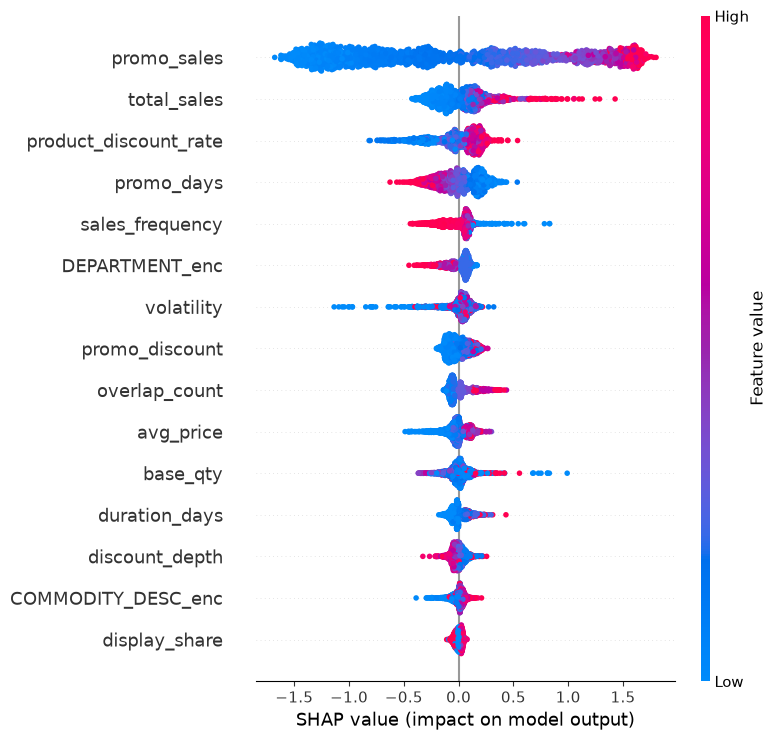


=== Regressor feature importance (gain) ===
              feature          gain
          promo_sales 133698.656322
           volatility  11046.627007
          total_sales   9728.912716
             base_qty   8784.808626
product_discount_rate   7769.532313
       promo_discount   6166.155953
            avg_price   5933.507390
           promo_days   3943.535126
      sales_frequency   3920.724813
       discount_depth   3441.357301
   COMMODITY_DESC_enc   3177.498416
        overlap_count   2348.271474


In [10]:
import shap
rng = np.random.default_rng(CFG.seed)
idx = rng.choice(len(Xtr), size=min(CFG.shap_sample, len(Xtr)), replace=False)
explainer = shap.TreeExplainer(reg)
shap_values = explainer.shap_values(Xtr.iloc[idx])
shap_df = pd.DataFrame(shap_values, columns=[f"shap_{c}" for c in FEATURE_COLS])
shap_out = pd.concat([train_df.iloc[idx][["CAMPAIGN", "PRODUCT_ID"]].reset_index(drop=True),
                      shap_df.reset_index(drop=True)], axis=1)
UC.save_parquet(shap_out, CFG.output_dir / "shap_values.parquet",
                logger=logger, context="shap_values")

shap.summary_plot(shap_values, Xtr.iloc[idx], feature_names=FEATURE_COLS, show=False,
                  max_display=15)
plt.tight_layout()
plt.savefig(CFG.figures_dir / "shap_summary.png", dpi=110, bbox_inches="tight")
plt.show()

imp = pd.DataFrame({"feature": reg.feature_name_,
                    "gain": reg.booster_.feature_importance(importance_type="gain")})
imp = imp.sort_values("gain", ascending=False).reset_index(drop=True)
print("\n=== Regressor feature importance (gain) ===")
print(imp.head(12).to_string(index=False))


# ### Business interpretation
#
# - **Demand scale** (`base_qty`, `total_sales`) and **discount depth** usually dominate:
#   bigger products generate bigger absolute increments, and deeper discounts move more
#   units — but recall from MVP 03 that deeper discounts also destroy profit.
# - **Product profile** (`volatility`, `product_discount_rate`) tells us which products
#   respond to promotions, and **season** (`quarter`) captures timing effects.
# - When `discount_depth` has high importance, the ranker is effectively learning
#   "shallower discounts on responsive products rank higher" — the same signal MVP 06
#   turns into a recommendation rule.


# ## 5. Rank All Historical Campaigns
#
# Campaign-level features are the instance features averaged over the products each
# campaign promoted. The regressor predicts a campaign business-value score, which we
# rank and compare with the observed composite rank from MVP 03.


In [11]:
camp_feats = inst.groupby("CAMPAIGN")[FEATURE_COLS].mean().reset_index()
camp_feats["pred_business_value"] = reg.predict(camp_feats[FEATURE_COLS])
camp_feats["pred_rank"] = camp_feats["pred_business_value"].rank(
    ascending=False, method="first").astype(int)
ranked = (camp_feats.merge(campaign_roi[["CAMPAIGN", "composite_rank", "rank_inc_rev",
                                         "roi", "incremental_rev",
                                         "incremental_profit"]],
                           on="CAMPAIGN", how="left")
          .sort_values("pred_rank"))
ranked["observed_rank"] = ranked["composite_rank"]
rho, pval = spearmanr(ranked["pred_rank"], ranked["observed_rank"])
rho_rev, _ = spearmanr(ranked["pred_rank"], ranked["rank_inc_rev"])
print(f"Spearman correlation (predicted vs observed composite rank): {rho:.3f} (p={pval:.3f})")
print(f"Spearman correlation (predicted vs observed REVENUE rank) : {rho_rev:.3f}")
print("""
Why the gap? The model predicts *revenue potential* (business value). The observed
composite rank mixes revenue with ROI/profit, and every campaign is profit-negative
at a 30% margin (MVP 03) — so profit ranking is nearly the inverse of revenue
ranking. The model is telling us what *sells*; converting that into what *pays*
requires the cost/margin layer, which MVP 06 combines with rules + optimization.
""")

UC.save_parquet(ranked, CFG.output_dir / "ranked_campaigns.parquet",
                logger=logger, context="ranked_campaigns")
print("\n=== Top 10 campaigns by predicted business value ===")
print(ranked.head(10)[["CAMPAIGN", "pred_business_value", "pred_rank", "observed_rank",
                       "roi", "incremental_rev"]].round(3).to_string(index=False))


Spearman correlation (predicted vs observed composite rank): -0.016 (p=0.934)
Spearman correlation (predicted vs observed REVENUE rank) : 0.868

Why the gap? The model predicts *revenue potential* (business value). The observed
composite rank mixes revenue with ROI/profit, and every campaign is profit-negative
at a 30% margin (MVP 03) — so profit ranking is nearly the inverse of revenue
ranking. The model is telling us what *sells*; converting that into what *pays*
requires the cost/margin layer, which MVP 06 combines with rules + optimization.

23:02:27 | INFO    | campaign_ranking | [ranked_campaigns] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/campaign_ranking/ranked_campaigns.parquet (30 rows x 30 cols)



=== Top 10 campaigns by predicted business value ===
 CAMPAIGN  pred_business_value  pred_rank  observed_rank    roi  incremental_rev
       20                4.105          1             16 -0.466       112170.213
       15                4.036          2             10 -0.444       241562.313
       18                3.834          3              7 -0.432        87900.632
       27                3.738          4             23 -0.492        88443.324
       14                3.701          5             13 -0.459        92475.805
        3                3.667          6              3 -0.422       103380.400
       28                3.557          7             27 -0.499        88257.513
       24                3.553          8             15 -0.466        79462.318
        8                3.467          9             19 -0.481        88569.275
       11                3.439         10              8 -0.440        78679.147


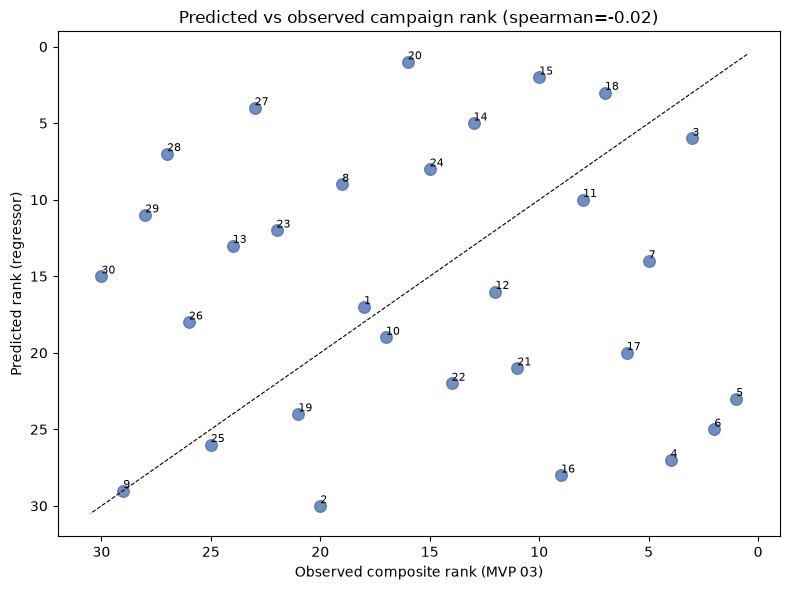

In [12]:
# Figure: predicted vs observed rank
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(ranked["observed_rank"], ranked["pred_rank"], s=70, alpha=0.8, color="#4c72b0")
for _, r in ranked.iterrows():
    ax.annotate(int(r["CAMPAIGN"]), (r["observed_rank"], r["pred_rank"]), fontsize=8,
                ha="left", va="bottom")
lim = [0.5, 30.5]
ax.plot(lim, lim, "k--", lw=0.8)
ax.set_xlabel("Observed composite rank (MVP 03)")
ax.set_ylabel("Predicted rank (regressor)")
ax.set_title(f"Predicted vs observed campaign rank (spearman={rho:.2f})")
ax.invert_xaxis(); ax.invert_yaxis()
plt.tight_layout()
fig.savefig(CFG.figures_dir / "predicted_vs_observed_rank.png", dpi=110)
plt.show()


In [13]:
metrics_all = {"rank_metrics": rank_metrics, "reg_metrics": reg_metrics,
               "campaign_rank_spearman": float(rho),
               "campaign_revenue_rank_spearman": float(rho_rev),
               "n_train_campaigns": len(train_campaigns),
               "n_valid_campaigns": len(valid_campaigns)}
UC.save_json(metrics_all, CFG.output_dir / "metrics.json", logger=logger, context="metrics")


23:02:29 | INFO    | campaign_ranking | [metrics] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/campaign_ranking/metrics.json


PosixPath('/home/mhseddighi/Projects/promotion-intelligence/outputs/campaign_ranking/metrics.json')

# ## 6. Validation — Exports, Schema and Reload


In [14]:
def validate_exports() -> None:
    out = CFG.output_dir
    ds = UC.reload_and_check(out / "ranking_dataset.parquet",
        expected=["CAMPAIGN", "PRODUCT_ID", "business_value"] + FEATURE_COLS,
        context="ranking_dataset")
    assert ds["CAMPAIGN"].nunique() == 30
    rk = UC.reload_and_check(out / "ranked_campaigns.parquet",
        expected=["CAMPAIGN", "pred_business_value", "pred_rank", "observed_rank"],
        context="ranked_campaigns")
    assert rk["pred_rank"].nunique() == len(rk)
    UC.reload_and_check(out / "shap_values.parquet",
        expected=[f"shap_{FEATURE_COLS[0]}"], context="shap_values")
    with open(out / "metrics.json") as f:
        m = json.load(f)
    assert np.isfinite(m["rank_metrics"]["ndcg"]) and np.isfinite(m["reg_metrics"]["ndcg"])
    print("PASS: MVP 05 exports validated")


validate_exports()


PASS [nan/inf] reload ranking_dataset.parquet: no NaN/Inf in 19,107 rows
PASS [schema] reload ranking_dataset.parquet: 36 columns OK
PASS [reload] ranking_dataset: ranking_dataset.parquet -> 19,107 rows
PASS [nan/inf] reload ranked_campaigns.parquet: no NaN/Inf in 30 rows
PASS [schema] reload ranked_campaigns.parquet: 30 columns OK
PASS [reload] ranked_campaigns: ranked_campaigns.parquet -> 30 rows
PASS [nan/inf] reload shap_values.parquet: no NaN/Inf in 2,000 rows
PASS [schema] reload shap_values.parquet: 23 columns OK
PASS [reload] shap_values: shap_values.parquet -> 2,000 rows
PASS: MVP 05 exports validated


In [15]:
# Pipeline manifest snippet
manifest = {
    "notebook": "08_campaign_ranking",
    "mvp": "MVP 05 — Campaign Ranking",
    "inputs": [
        "outputs/baseline_forecast/incremental_product.parquet",
        "outputs/baseline_forecast/encoders.pkl",
        "outputs/roi_analysis/campaign_roi_summary.parquet",
        "outputs/promotion_analysis/promoted_products.parquet",
        "outputs/promotion_analysis/campaign_overlaps.parquet",
        "outputs/product_intelligence/product_features.parquet",
        "data/processed/causal_weekly.parquet",
    ],
    "outputs": [
        "outputs/campaign_ranking/ranking_dataset.parquet",
        "outputs/campaign_ranking/model_ranker.pkl",
        "outputs/campaign_ranking/model_regressor.pkl",
        "outputs/campaign_ranking/ranked_campaigns.parquet",
        "outputs/campaign_ranking/shap_values.parquet",
        "outputs/campaign_ranking/metrics.json",
    ],
    "artifacts": {
        "model_ranker.pkl": "LightGBM LambdaRank (product-query groups)",
        "model_regressor.pkl": "interpretable regression baseline used for SHAP + campaign ranking",
        "ranked_campaigns.parquet": "all campaigns ranked by predicted business value",
    },
}
print(json.dumps(manifest, indent=2))


{
  "notebook": "08_campaign_ranking",
  "mvp": "MVP 05 \u2014 Campaign Ranking",
  "inputs": [
    "outputs/baseline_forecast/incremental_product.parquet",
    "outputs/baseline_forecast/encoders.pkl",
    "outputs/roi_analysis/campaign_roi_summary.parquet",
    "outputs/promotion_analysis/promoted_products.parquet",
    "outputs/promotion_analysis/campaign_overlaps.parquet",
    "outputs/product_intelligence/product_features.parquet",
    "data/processed/causal_weekly.parquet"
  ],
  "outputs": [
    "outputs/campaign_ranking/ranking_dataset.parquet",
    "outputs/campaign_ranking/model_ranker.pkl",
    "outputs/campaign_ranking/model_regressor.pkl",
    "outputs/campaign_ranking/ranked_campaigns.parquet",
    "outputs/campaign_ranking/shap_values.parquet",
    "outputs/campaign_ranking/metrics.json"
  ],
  "artifacts": {
    "model_ranker.pkl": "LightGBM LambdaRank (product-query groups)",
    "model_regressor.pkl": "interpretable regression baseline used for SHAP + campaign ranking